In [1]:
import torch 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import open3d as o3d
from typing import Tuple


#device = torch.device("cuda") if use_cuda and torch.cuda.is_available() else torch.device("cpu")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


Using: cpu


In [2]:
#IMPORT LIDAR DATA 

file_path1 = r"C:/Users/joven/OneDrive/Documents/Ml-Projects/adaptive-dbscan-core/Lidar_Data/Lidar_data_testH/scan_00000.npy"
file_path2 = r"C:/Users/joven/OneDrive/Documents/Ml-Projects/adaptive-dbscan-core/Lidar_Data/Lidar_data_testH/scan_00001.npy"

points1 = np.load(file_path1).astype(np.float32)
points2 = np.load(file_path2).astype(np.float32)

points = np.vstack([points1, points2])   # stack vertically

print(type(points))
print(points.shape)
print(points.dtype)

<class 'numpy.ndarray'>
(256000, 3)
float32


In [3]:
#TRIM LIDAR DATA  -  only keep dimensions -2.5<y<2.5, 30>x>2, z<1

mask = (
    (points[:, 1] > -2.5) &
    (points[:, 1] <  2.5) &
    (points[:, 0] > 2) &
    (points[:, 0] < 30) &
    (points[:,2] < 0.5)
)

trimmed_points = points[mask]

print("Trimmed shape:", trimmed_points.shape)



#PLOT TRIMMED POINTS AND SHAPE 

# Make sure trimmed_points is float64 or float32

"""
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(trimmed_points)

vis = o3d.visualization.Visualizer()
vis.create_window(width=1200, height=800)
vis.add_geometry(pcd)

opt = vis.get_render_option()
opt.point_size = 1.0
opt.background_color = np.array([0.05, 0.05, 0.08])

# --- Camera control ---
ctr = vis.get_view_control()

# Center view at XY center, Z = 0
xy_center = np.mean(points[:, :2], axis=0)
lookat = [xy_center[0], xy_center[1], 0.0]

ctr.set_lookat(lookat)
ctr.set_up([0, 0, 1])        # Z is up
ctr.set_front([-1, 0, 0.5])  # nice angled view
ctr.set_zoom(0.2)

vis.run()
vis.destroy_window()
"""



Trimmed shape: (62961, 3)


'\npcd = o3d.geometry.PointCloud()\npcd.points = o3d.utility.Vector3dVector(trimmed_points)\n\nvis = o3d.visualization.Visualizer()\nvis.create_window(width=1200, height=800)\nvis.add_geometry(pcd)\n\nopt = vis.get_render_option()\nopt.point_size = 1.0\nopt.background_color = np.array([0.05, 0.05, 0.08])\n\n# --- Camera control ---\nctr = vis.get_view_control()\n\n# Center view at XY center, Z = 0\nxy_center = np.mean(points[:, :2], axis=0)\nlookat = [xy_center[0], xy_center[1], 0.0]\n\nctr.set_lookat(lookat)\nctr.set_up([0, 0, 1])        # Z is up\nctr.set_front([-1, 0, 0.5])  # nice angled view\nctr.set_zoom(0.2)\n\nvis.run()\nvis.destroy_window()\n'

In [4]:
#VOXEL DOWNSAMPLING 






torch.Size([1358, 3])
Best_n = tensor([ 0.0125, -0.0073,  0.9999])
Best_d = -0.05072665214538574
torch.Size([1358, 2])


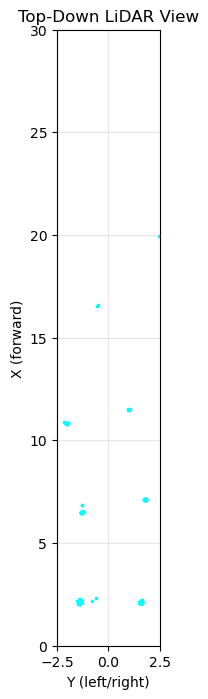

In [5]:
#RANSAC 
points = torch.from_numpy(trimmed_points) 


def fit_plane(
        p1,
        p2,
        p3,
        eps:float = 1e-12,
        require_vertical: 
        bool = True, 
        vertical_co_thresh: float = 0.7
): 
   
   
    v1 = p2 - p3
    v2 = p3 - p1

    n = torch.cross(v1,v2,dim=0)
    mag_n = torch.linalg.norm(n)
    n = n/(mag_n + eps) 

    ok = (mag_n > eps) and (torch.abs(n[2]) >= vertical_co_thresh)

    d = -torch.dot(n,p1)

    return n,d,ok

def num_inliers(points, n, d,distance_thresh): 
    dist = (points@n + d).abs()
    mask_c = dist < distance_thresh
    inliers_c = int(mask_c.sum().item())
    return inliers_c,dist

def RANSAC(
    points: torch.Tensor,
    num_iters: int = 60,
    distance_thresh: float = 0.03,                
    min_inliers: int = 500,
    lowest_z_frac: float = 0.5,
    early_stop_inlier_ratio: float = 1,
    seed: int = 0,
    refine: bool = True,
):
    
    #Check points dimensions and move to GPU
    assert points.ndim == 2 and points.shape[1] == 3 
    device = points.device 

    N = points.shape[0]

    #determine candidate idx for RANSAC 
    if lowest_z_frac is not None and 0 < lowest_z_frac < 1.0:
        z = points[:,2]
        K = max(3,int(math.ceil(N*lowest_z_frac)))

        cand_idx = torch.topk(z, k=K, largest=False).indices
    else: 
        cand_idx = torch.arange(N, device=device)
    
    cand_points = points[cand_idx]
    K = cand_points.shape[0]

    #random generator on GPU 
    g = torch.Generator(device=device)
    g.manual_seed(seed)

    #best guess variables 
    best_inliers = 0
    best_n,best_d = None,None
    best_mask = None

    #RANSAC algo
    for i in range(num_iters): 
        s = torch.randint(0,K, (3,),generator=g,device=device)
        p1,p2,p3 = cand_points[s[0]],cand_points[s[1]],cand_points[s[2]]

        n,d,ok = fit_plane(p1,p2,p3)

        if not bool(ok):
            continue 

        inliers_c,dist = num_inliers(points,n,d,distance_thresh) 
        if inliers_c > best_inliers:
            best_inliers = inliers_c
            best_n,best_d = n,d 

            best_mask = dist < distance_thresh

            if best_inliers/N >= early_stop_inlier_ratio:
                break 

    return best_n,best_d,best_mask

best_n, best_d, best_mask = RANSAC(
    points,
    num_iters=800,
    distance_thresh=0.05,
    min_inliers=100,
    lowest_z_frac=None,      # set e.g. 0.5 if you want to bias sampling
    early_stop_inlier_ratio=1,
    seed=0,  # set True if you want |nz| >= vertical_co_thresh
)


points = points[~best_mask] 
print(points.shape)

print(f"Best_n = {best_n}")
print(f"Best_d = {best_d}")



#PLOT 3D RANSAC-FILTERED POINTS


plot_points = points.detach().numpy()

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(plot_points)

vis = o3d.visualization.Visualizer()
vis.create_window(width=1200, height=800)
vis.add_geometry(pcd)

opt = vis.get_render_option()
opt.point_size = 1.0
opt.background_color = np.array([0.05, 0.05, 0.08])

# --- Camera control ---
ctr = vis.get_view_control()

# Center view at XY center, Z = 0
xy_center = np.mean(plot_points[:, :2], axis=0)
lookat = [xy_center[0], xy_center[1], 0.0]

ctr.set_lookat(lookat)
ctr.set_up([0, 0, 1])        # Z is up
ctr.set_front([-1, 0, 0.5])  # nice angled view
ctr.set_zoom(0.2)

vis.run()
vis.destroy_window()



#FLATTEN AND PLOT 2D POINTS 

points = points[:,:2]
print(points.shape)



flattened_points_plot = points.detach().numpy()

x = flattened_points_plot[:, 0]  # forward
y = flattened_points_plot[:, 1]  # lateral

plt.figure(figsize=(6, 8))  # taller since forward axis is longer

plt.scatter(
    -y,        # horizontal axis = lateral
    x,        # vertical axis = forward
    s=2,
    c='cyan'
)

plt.xlim(-2.5, 2.5)   # lateral bounds
plt.ylim(0, 30)       # forward bounds

plt.gca().set_aspect('equal', adjustable='box')

plt.xlabel("Y (left/right)")
plt.ylabel("X (forward)")
plt.title("Top-Down LiDAR View")

plt.grid(True, alpha=0.3)
plt.show()



In [ ]:
#DBSCAN PARAMS

## reason this is all being created. Need adaptive epsilon and min samples to accomdate relative radial resolution of the lidar sensor
distances = torch.norm(points, p=2, dim=1)

#coefficients (tunable on real data)
a = 0.03
b = 0.2
min_samples_min = 5
mins_samples_max = 200
K = 1000
epsilons = a*distances + b

min_samples = torch.ceil(K / (distances ** 2)).to(torch.int64) 
min_samples = torch.maximum(min_samples, torch.tensor(min_samples_min, device=device))
min_samples = torch.minimum(min_samples, torch.tensor(mins_samples_max, device=device))


In [7]:
def grid_coords(points: torch.Tensor, cell: float):
    # points: (N, 2) float tensor
    # returns cx, cy: (N,) long tensors (integer cell coordinates)
    cx = torch.floor(points[:, 0] / cell).long()
    cy = torch.floor(points[:, 1] / cell).long()
    return cx, cy


def build_edges_grid_adaptive_eps_sorted(
    points: torch.Tensor,
    eps_i: torch.Tensor,
    cell_quantile: float = 0.90,
    min_cell: float = 0.2,
    block: int = 4096,
    cap_R_at_1: bool = True,   # set False if you really need larger R
) -> Tuple[torch.Tensor, torch.Tensor]:
    device = points.device
    N = points.shape[0]

    eps_max = eps_i.max().item()

    # quantile on-device (avoid CPU roundtrip)
    cell = torch.quantile(eps_i.detach(), cell_quantile).item()
    cell = max(cell, min_cell)

    if cap_R_at_1:
        cell = max(cell, eps_max)  # ensures R=1

    R = max(1, int(math.ceil(eps_max / cell)))
    if cap_R_at_1:
        R = min(R, 1)

    # integer cell coords (on device)
    cx = torch.floor(points[:, 0] / cell).to(torch.int64)
    cy = torch.floor(points[:, 1] / cell).to(torch.int64)

    # pack (cx,cy) -> single int64 cell id
    # choose a stride big enough so ids don't collide
    # (you can also use hashing, but this is simple & fast)
    cy_min = cy.min()
    cy_shift = cy - cy_min
    stride = (cy_shift.max().item() + 1) + (2 * R + 3)  # safe margin
    cell_id = cx * stride + cy_shift

    # sort points by cell_id once
    order = torch.argsort(cell_id)
    cell_sorted = cell_id[order]

    # find unique cells and [start,end) ranges in the sorted array
    uniq, counts = torch.unique_consecutive(cell_sorted, return_counts=True)
    starts = torch.cumsum(torch.cat([counts.new_zeros(1), counts[:-1]]), dim=0)
    ends = starts + counts

    # move uniq to CPU for dict lookup (small: ~#cells)
    uniq_cpu = uniq.detach().cpu().tolist()
    starts_cpu = starts.detach().cpu().tolist()
    ends_cpu = ends.detach().cpu().tolist()

    ranges = {cid: (s, e) for cid, s, e in zip(uniq_cpu, starts_cpu, ends_cpu)}

    # precompute offset list
    offsets = [(dx, dy) for dx in range(-R, R + 1) for dy in range(-R, R + 1)]

    src_chunks = []
    dst_chunks = []

    # iterate over occupied cells (still Python loop, but far fewer expensive ops inside)
    for cid, s, e in zip(uniq_cpu, starts_cpu, ends_cpu):
        I = order[s:e]          # (a,) indices of points in this cell
        Pi = points[I]          # (a,2)
        eps2_i = (eps_i[I] ** 2)[:, None]  # (a,1)

        gx = cid // stride
        gy_shift = cid - gx * stride

        # gather neighbor indices by slicing the sorted order tensor
        neigh_slices = []
        for dx, dy in offsets:
            ncx = gx + dx
            ncy_shift = gy_shift + dy
            ncid = int(ncx * stride + ncy_shift)
            r = ranges.get(ncid)
            if r is not None:
                ns, ne = r
                neigh_slices.append(order[ns:ne])

        if not neigh_slices:
            continue

        J = torch.cat(neigh_slices, dim=0)   # (b,)
        Pj = points[J]                       # (b,2)

        # blocked compare over J to avoid OOM
        b = Pj.shape[0]
        for start in range(0, b, block):
            end = min(start + block, b)
            Pjb = Pj[start:end]     # (bb,2)
            Jb  = J[start:end]      # (bb,)

            # use cdist (often faster than manual broadcast)
            dist2 = torch.cdist(Pi, Pjb, p=2) ** 2   # (a,bb)
            mask = dist2 <= eps2_i                   # (a,bb)

            ii, jj = torch.where(mask)
            if ii.numel():
                src_chunks.append(I[ii])
                dst_chunks.append(Jb[jj])

    if not src_chunks:
        empty = torch.empty(0, dtype=torch.long, device=device)
        return empty, empty

    src = torch.cat(src_chunks, dim=0)
    dst = torch.cat(dst_chunks, dim=0)

    keep = src != dst
    return src[keep], dst[keep]


def dbscan_from_edges(N, src, dst, min_samples, max_iters=50):
    device = src.device

    # 1) neighbour counts
    counts = torch.bincount(src, minlength=N)
    
    # 2) core points
    core = counts >= min_samples

    # 3) keep only core-core neighbour relations (for forming core clusters)
    mask_cc = core[src] & core[dst]
    cc_src0 = src[mask_cc]
    cc_dst0 = dst[mask_cc]

    cc_src = torch.cat([cc_src0, cc_dst0], dim=0)
    cc_dst = torch.cat([cc_dst0, cc_src0], dim=0)


    # 4) label spreading among core points
    labels = torch.full((N,), -1, device=device, dtype=torch.long)
    labels[core] = torch.arange(N, device=device, dtype=torch.long)[core]

    for _ in range(max_iters):
        old = labels
        cand = old[cc_src]
        new = old.clone()
        new.scatter_reduce_(0, cc_dst, cand, reduce="amin", include_self=True)
        labels = new
        if torch.equal(labels, old):
            break

    # 5) compress root labels into 0..K-1 cluster IDs (cores only)
    cluster = torch.full((N,), -1, device=device, dtype=torch.long)
    roots = labels[core]
    if roots.numel() > 0:
        unique_roots, inv = torch.unique(roots, sorted=True, return_inverse=True)
        cluster[core] = inv

    # 6) attach border points: core -> noncore
    mask_cb = (~core[src]) & (core[dst])
    cb_src = src[mask_cb]   # core points
    cb_dst = dst[mask_cb]   # border candidates

    if cb_dst.numel() > 0:
        cand_clusters = cluster[cb_src]      # cluster of the core
        cluster2 = cluster.clone()
        cluster2.scatter_reduce_(0, cb_dst, cand_clusters, reduce="amin", include_self=True)
        cluster = cluster2


    return cluster, core, counts



src, dst = build_edges_grid_adaptive_eps_sorted(points,epsilons)
cluster,core,counts = dbscan_from_edges(points.size(dim=0), src, dst, min_samples, max_iters=500)



#testing purposes - print out clusters
points_cpu = points.detach().cpu()
cluster_cpu = cluster.detach().cpu()

valid = cluster_cpu >= 0

cluster_ids = torch.unique(cluster_cpu[valid])
num_clusters = cluster_ids.numel()

print("Num clusters:", num_clusters)
print("Num noise:", (cluster_cpu == -1).sum().item())

# Sizes: bincount works nicely because cluster ids are 0..K-1 in our pipeline
# If you’re not sure they’re contiguous, we’ll compute sizes by unique counts:
u, counts = torch.unique(cluster_cpu[valid], return_counts=True)
# Sort by cluster id
order = torch.argsort(u)
u = u[order]
counts = counts[order]

print("\nCluster sizes (cluster_id -> size):")
for cid, sz in zip(u.tolist(), counts.tolist()):
    print(f"  {cid+1:>3} -> {sz}")


K = int(cluster_ids.max().item()) + 1  # assumes cluster ids start at 0
pts = points_cpu  # (N,2)

# Sum coordinates per cluster
sums = torch.zeros((K, 2), dtype=pts.dtype)
sums.index_add_(0, cluster_cpu[valid], pts[valid])

# Counts per cluster (same ordering as sums)
cnts = torch.zeros((K,), dtype=torch.long)
cnts.index_add_(0, cluster_cpu[valid], torch.ones((valid.sum(),), dtype=torch.long))

# Centroids (avoid divide by zero)
centroids = sums / cnts.clamp(min=1).unsqueeze(1)  # (K,2)

print("\nCluster centroids (cluster_id -> (mean_x, mean_y)):")
for cid in range(K):
    if cnts[cid].item() == 0:
        continue
    mx, my = centroids[cid].tolist()
    print(f"  {cid+1:>3} -> ({mx:.3f}, {my:.3f})  size={cnts[cid].item()}")



Num clusters: 5
Num noise: 31

Cluster sizes (cluster_id -> size):
    1 -> 701
    2 -> 70
    3 -> 38
    4 -> 55
    5 -> 463

Cluster centroids (cluster_id -> (mean_x, mean_y)):
    1 -> (2.148, 1.351)  size=701
    2 -> (6.501, 1.285)  size=70
    3 -> (10.840, 2.027)  size=38
    4 -> (7.109, -1.794)  size=55
    5 -> (2.111, -1.576)  size=463


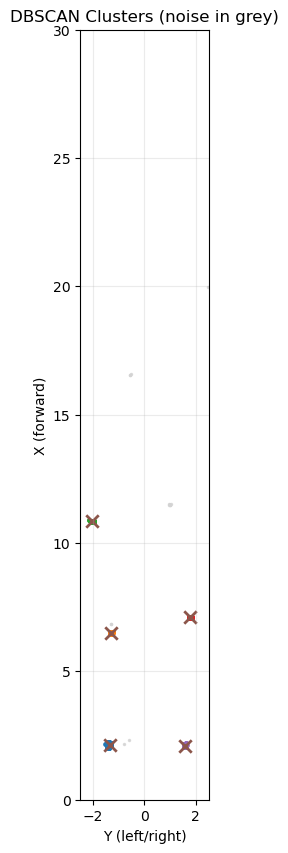

In [8]:

# --- convert to numpy ---
pts = points_cpu.numpy()              # (N,2)
lab = cluster_cpu.numpy().astype(int) # (N,)

# --- masks ---
noise = (lab == -1)
valid = ~noise

# --- plot ---
plt.figure(figsize=(7, 10))

# Noise first (small + faint)
plt.scatter(
    -pts[noise, 1], pts[noise, 0],      # x-axis = Y (across), y-axis = X (away)
    s=2, c="lightgray", alpha=0.5, label="noise"
)

# Clusters
cluster_ids = np.unique(lab[valid])
for cid in cluster_ids:
    m = (lab == cid)
    plt.scatter(
        -pts[m, 1], pts[m, 0],
        s=6, alpha=0.9, label=f"cluster {cid}"
    )

# Optional: centroids if you computed them (torch tensor centroids (K,2))
if "centroids" in globals():
    cen = centroids.detach().cpu().numpy()  # (K,2)
    # plot as X markers (remember axis swap)
    plt.scatter(-cen[:, 1], cen[:, 0], marker="x", s=80, linewidths=2, label="centroids")

# Axes limits you were using
plt.xlim(-2.5, 2.5)   # lateral
plt.ylim(0, 30)       # forward

plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("Y (left/right)")
plt.ylabel("X (forward)")
plt.title("DBSCAN Clusters (noise in grey)")

plt.grid(True, alpha=0.25)

# If you have many clusters, legend gets huge; comment out if annoying.
# plt.legend(loc="upper right", fontsize=8, markerscale=2)

plt.show()
